In [3]:
import sys
import os

# Add project root to path
sys.path.append(os.path.abspath(".."))

In [5]:
import os
print(os.getcwd())

/Users/divyanshsingh/volatility-forecasting/notebooks


In [6]:
from src.data_loader import load_data

data = load_data()
data.head()

,Close,High,Low,Open,Volume
Date,,,,,
2015-01-02,8395.450195,8410.599609,8288.700195,8288.700195,101900
2015-01-05,8378.400391,8445.599609,8363.900391,8407.950195,118200
2015-01-06,8127.350098,8327.849609,8111.350098,8325.299805,172800
2015-01-07,8102.100098,8151.200195,8065.450195,8118.649902,164100
2015-01-08,8234.599609,8243.500000,8167.299805,8191.399902,143800


In [7]:
import numpy as np

data['returns'] = np.log(data['Close'] / data['Close'].shift(1))
data = data.dropna()

data.head()

,Close,High,Low,Open,Volume,returns
Date,,,,,,
2015-01-05,8378.400391,8445.599609,8363.900391,8407.950195,118200,-0.002033
2015-01-06,8127.350098,8327.849609,8111.350098,8325.299805,172800,-0.030422
2015-01-07,8102.100098,8151.200195,8065.450195,8118.649902,164100,-0.003112
2015-01-08,8234.599609,8243.500000,8167.299805,8191.399902,143800,0.016221
2015-01-09,8284.500000,8303.299805,8190.799805,8285.450195,148000,0.006042


In [8]:
data['volatility'] = data['returns'].rolling(window=21).std()

Matplotlib is building the font cache; this may take a moment.


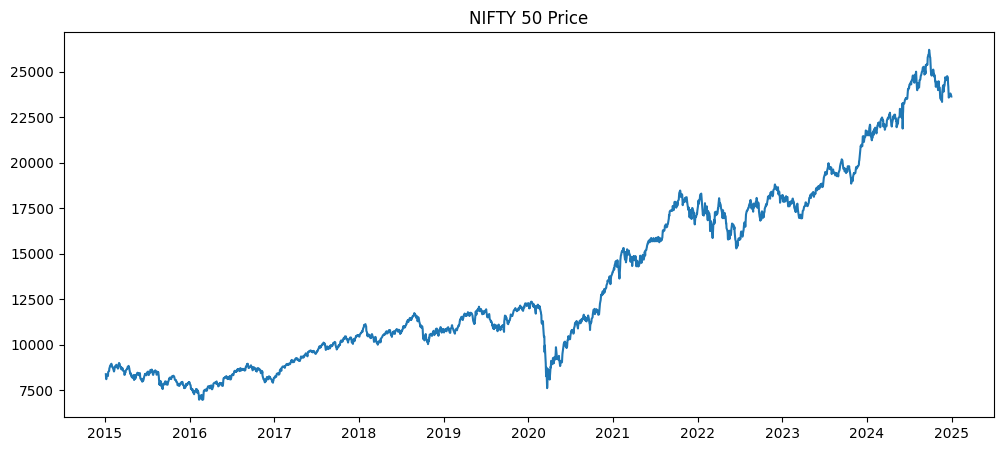

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(data['Close'])
plt.title("NIFTY 50 Price")
plt.show()


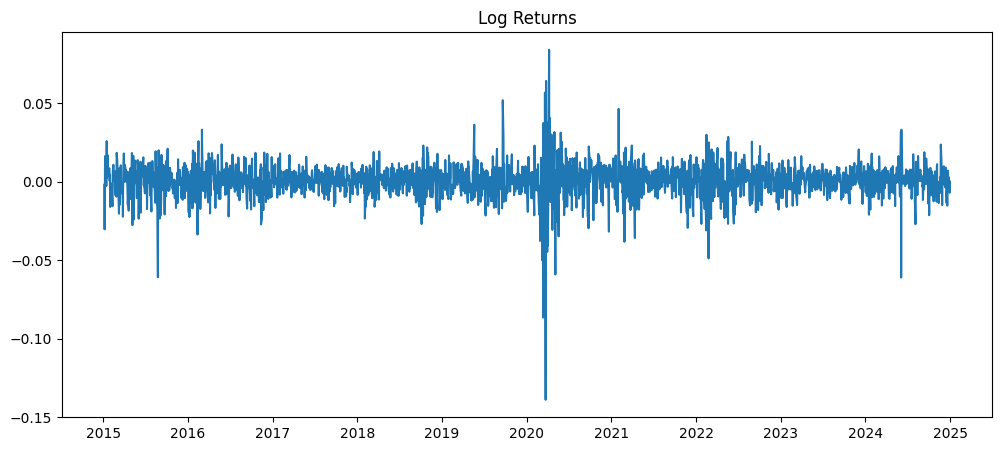

In [10]:
plt.figure(figsize=(12,5))
plt.plot(data['returns'])
plt.title("Log Returns")
plt.show()

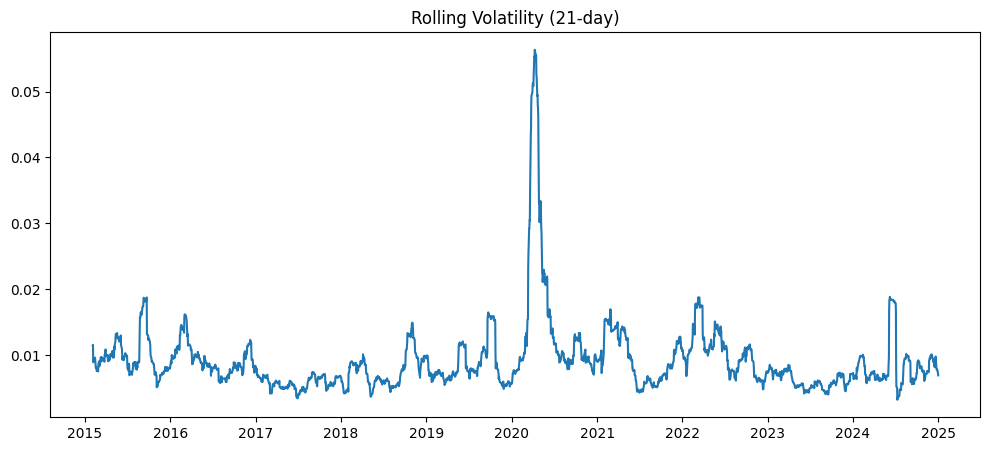

In [11]:
plt.figure(figsize=(12,5))
plt.plot(data['volatility'])
plt.title("Rolling Volatility (21-day)")
plt.show()

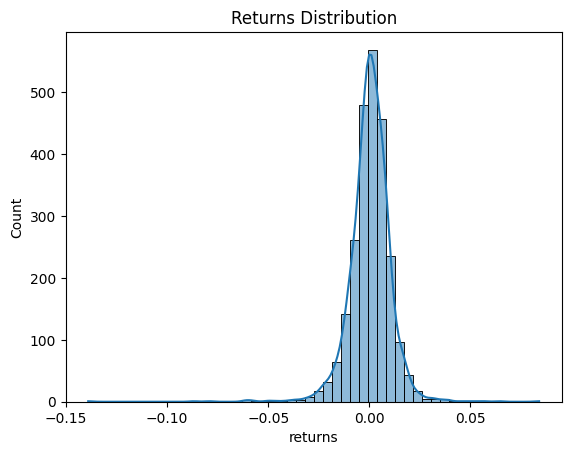

In [12]:
import seaborn as sns

sns.histplot(data['returns'], bins=50, kde=True)
plt.title("Returns Distribution")
plt.show()

In [13]:
print("Mean:", data['returns'].mean())
print("Std Dev:", data['returns'].std())
print("Skewness:", data['returns'].skew())
print("Kurtosis:", data['returns'].kurtosis())

Mean: 0.0004212584763877047
Std Dev: 0.010544510330737828
Skewness: -1.4076433442807548
Kurtosis: 20.41323623527168


In [16]:
data.to_csv("../data/nifty50_processed.csv")